In [1]:
import torch
print(torch.__version__)

2.9.0


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

Training on device: mps

--- Problem 1: Sine Wave ---
Epoch 1000/8000, Total Loss: 5.890673e-03
Epoch 2000/8000, Total Loss: 5.231753e-04
Epoch 3000/8000, Total Loss: 4.198421e-04
Epoch 4000/8000, Total Loss: 2.876353e-04
Epoch 5000/8000, Total Loss: 2.749536e-04
Epoch 6000/8000, Total Loss: 1.824421e-03
Epoch 7000/8000, Total Loss: 1.379072e-03
Epoch 8000/8000, Total Loss: 7.498269e-06
Time: 54.20s
  Max Error : 0.000021 | Rel L2: 0.000018

--- Problem 2: Polynomial ---
Epoch 1000/8000, Total Loss: 8.612422e-05
Epoch 2000/8000, Total Loss: 4.059214e-05
Epoch 3000/8000, Total Loss: 2.387681e-05
Epoch 4000/8000, Total Loss: 1.873059e-04
Epoch 5000/8000, Total Loss: 4.743833e-06
Epoch 6000/8000, Total Loss: 2.848922e-06
Epoch 7000/8000, Total Loss: 5.400491e-06
Epoch 8000/8000, Total Loss: 2.182125e-06
Time: 52.66s
  Max Error : 0.000117 | Rel L2: 0.000482

--- Problem 3: High-Freq Sine ---
Epoch 1000/8000, Total Loss: 3.845902e-02
Epoch 2000/8000, Total Loss: 3.406034e-03
Epoch 3000/800

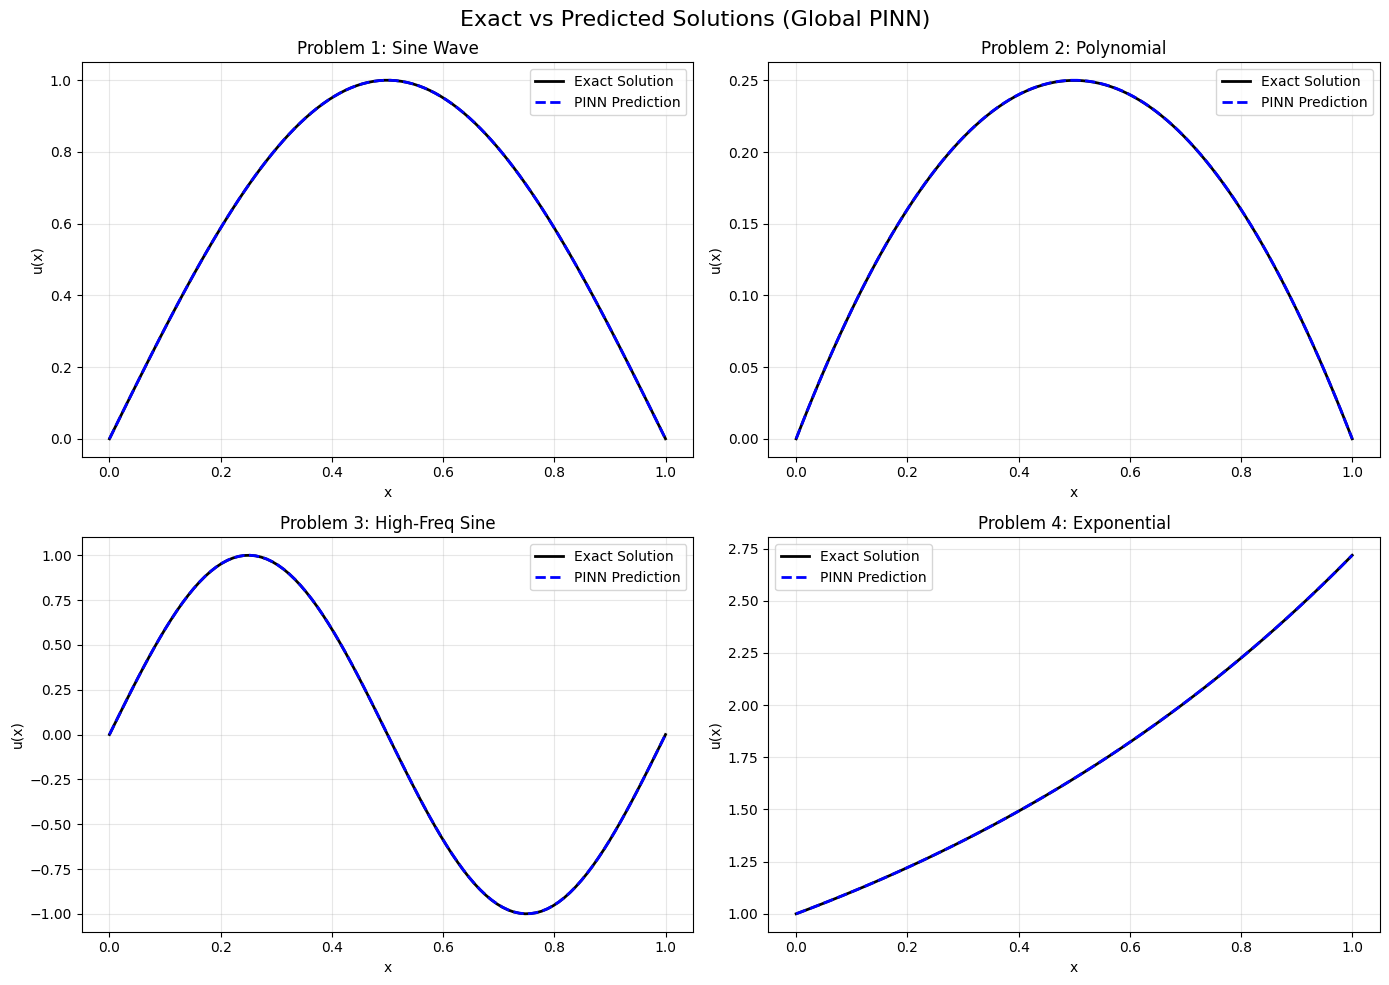

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)

# 1. HARDWARE PARITY
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. CAPACITY PARITY (Widened to 47 to match two 32-width networks)
class HardPINN(nn.Module):
    def __init__(self, x_left, x_right, u_left, u_right):
        super().__init__()
        self.x_left  = x_left
        self.x_right = x_right
        self.u_left  = u_left
        self.u_right = u_right
        self.net = nn.Sequential(
            nn.Linear(1, 47), nn.Tanh(),
            nn.Linear(47, 47), nn.Tanh(),
            nn.Linear(47, 47), nn.Tanh(),
            nn.Linear(47, 1)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        xl = torch.tensor([[self.x_left]],  dtype=torch.float32, device=device)
        xr = torch.tensor([[self.x_right]], dtype=torch.float32, device=device)
        ua = torch.tensor([[self.u_left]],  dtype=torch.float32, device=device)
        ub = torch.tensor([[self.u_right]], dtype=torch.float32, device=device)
        lift = ua + (x - xl) / (xr - xl) * (ub - ua)
        D    = (x - xl) * (x - xr)
        return lift + D * self.net(x)

def create_model(x_left=0.0, x_right=1.0, u_left=0.0, u_right=0.0):
    return HardPINN(x_left, x_right, u_left, u_right).to(device)

def compute_loss(model, f, x_interior):
    x_interior = x_interior.clone().detach().requires_grad_(True)
    u    = model(x_interior)
    du   = torch.autograd.grad(u,  x_interior, grad_outputs=torch.ones_like(u),  create_graph=True)[0]
    d2u  = torch.autograd.grad(du, x_interior, grad_outputs=torch.ones_like(du), create_graph=True)[0]
    L_pde = torch.mean((-d2u - f(x_interior)) ** 2)
    return L_pde, L_pde.item(), 0.0

# 3. STRICT COMPUTATIONAL BUDGET (No early stopping, no schedulers)
def train(model, f, epochs=8000, n_collocation=1000, lr=0.001, x_l=0.0, x_r=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'total_loss': [], 'pde_loss': [], 'bc_loss': []}

    t_start = time.perf_counter()
    for epoch in range(epochs):
        x_interior = x_l + (x_r - x_l) * torch.rand((n_collocation, 1), dtype=torch.float32, device=device)
        x_interior.requires_grad_(True)

        loss, pde_loss, bc_loss = compute_loss(model, f, x_interior)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['total_loss'].append(loss.item())
        history['pde_loss'].append(pde_loss)
        history['bc_loss'].append(bc_loss)

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Total Loss: {loss.item():.6e}")

    t_end = time.perf_counter()
    return history, t_end - t_start

def evaluate(model, exact_solution):
    model.eval()
    x_test = torch.linspace(0, 1, 100, device=device).unsqueeze(1)
    with torch.no_grad():
        u_pred = model(x_test).cpu().numpy()
    
    u_exact = exact_solution(x_test).cpu().numpy()
    error = np.abs(u_pred - u_exact)

    metrics = {'max_err': np.max(error), 'mean_err': np.mean(error), 'rel_l2': np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)}
    print(f"  Max Error : {metrics['max_err']:.6f} | Rel L2: {metrics['rel_l2']:.6f}")
    return x_test.cpu().numpy(), u_pred, u_exact, error, metrics

# --- RUN EXPERIMENTS ---
timing_records = []
plot_data = [] # MODIFICATION 1: Create a list to store plot data

problems = [
    ("Problem 1: Sine Wave", lambda x: (torch.pi**2) * torch.sin(torch.pi * x), lambda x: torch.sin(torch.pi * x), 0.0, 0.0),
    ("Problem 2: Polynomial", lambda x: 2.0 * torch.ones_like(x), lambda x: x * (1 - x), 0.0, 0.0),
    ("Problem 3: High-Freq Sine", lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x), lambda x: torch.sin(2 * torch.pi * x), 0.0, 0.0),
    ("Problem 4: Exponential", lambda x: -torch.exp(x), lambda x: torch.exp(x), 1.0, float(np.exp(1.0)))
]

for name, f, exact, ul, ur in problems:
    print(f"\n--- {name} ---")
    net = create_model(u_left=ul, u_right=ur)
    history, elapsed = train(net, f, epochs=8000, lr=0.001)
    print(f"Time: {elapsed:.2f}s")
    
    # MODIFICATION 2: Unpack the spatial coordinates and predictions returned by evaluate()
    x_val, u_p, u_e, error, metrics = evaluate(net, exact)
    
    timing_records.append({'problem': name, 'train_time_s': elapsed, **metrics})
    plot_data.append((name, x_val, u_p, u_e)) # Save for plotting later

print("\nGLOBAL PINN SUMMARY:")
for r in timing_records:
    print(f"{r['problem']:<25} | Time: {r['train_time_s']:>6.2f}s | Rel L2: {r['rel_l2']:.6f}")

# MODIFICATION 3: Generate the 2x2 comparison grid at the very end
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exact vs Predicted Solutions (Global PINN)", fontsize=16)

for ax, (name, x_val, u_p, u_e) in zip(axes.flatten(), plot_data):
    ax.plot(x_val, u_e, 'k-', linewidth=2, label="Exact Solution")
    ax.plot(x_val, u_p, 'b--', linewidth=2, label="PINN Prediction") # Using blue dashed line for the Global prediction
    
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()